In [13]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\tomkn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\tomkn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

C:\Users\tomkn\AppData\Local\Temp\ipykernel_16532\552120828.py:18: DtypeWarning:

Columns (3,6,7,9,30,36) have mixed types. Specify dtype option on import or set low_memory=False.



Filtering fake players...
Data shape after dropping nulls: (8170, 47)
Training data shape: (6576, 96), Test data shape: (950, 96)
Epoch 10/50, Loss: 114.5722
Epoch 20/50, Loss: 15.2036
Epoch 30/50, Loss: 25.4825
Epoch 40/50, Loss: 105.1903
Epoch 50/50, Loss: 86.8007
PyTorch Feedforward Model Results — MAE: 13.404, RMSE: 20.988


C:\Users\tomkn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



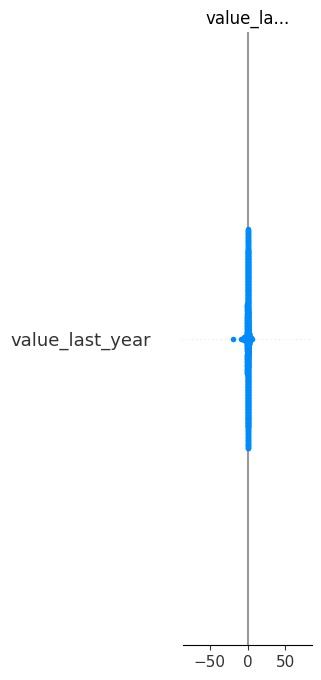

In [14]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import uuid

import plotly.express as px
import shap

from utils.model import test_train_split, define_features
from config import features, test_start, target, filter_out_synthetic, filter_out_fake_players

# === Load dataset ===
pdf_mvp = pd.read_csv("data/intermediate/time_series_model_data_prep.csv")

if filter_out_synthetic:
    print("Filtering synthetic players...")
    pdf_mvp = pdf_mvp[pdf_mvp["synthetic_flag"] == False]

if filter_out_fake_players:
    print("Filtering fake players...")
    pdf_mvp = pdf_mvp[pdf_mvp["player_id"] > 0]

# === Sort by player and year to maintain time-series order ===
pdf_mvp = pdf_mvp.sort_values(["player_id", "year"])

# === Drop rows with nulls in features or target ===
pdf_mvp = pdf_mvp.dropna(subset=features + [target])
print(f"Data shape after dropping nulls: {pdf_mvp.shape}")

version = "v0.0.1"
forecast_id = uuid.uuid4()

# === Define features ===
features = define_features(pdf_mvp, features)

# === Train-test split ===
pdf_train, pdf_test = test_train_split(pdf_mvp, test_start)

X_train = pdf_train[features].values
y_train = pdf_train[target].values

X_test = pdf_test[features].values
y_test = pdf_test[target].values

def main(X_train, y_train, X_test, y_test, timesteps: int = 3, epochs: int = 50, batch_size: int = 32):
    # === Scale features ===
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # === Convert to sequences ===
    def create_sequences(X, y, timesteps=3):
        Xs, ys = [], []
        for i in range(len(X) - timesteps):
            Xs.append(X[i:(i + timesteps)])
            ys.append(y[i + timesteps])
        return np.array(Xs), np.array(ys)

    X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

    # Flatten sequences for feedforward network
    X_train_seq = X_train_seq.reshape(X_train_seq.shape[0], -1)
    X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], -1)

    print(f"Training data shape: {X_train_seq.shape}, Test data shape: {X_test_seq.shape}")

    # === Convert to PyTorch tensors ===
    X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # === Define model ===
    model = nn.Sequential(
        nn.Linear(X_train_seq.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # === Train ===
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            preds_batch = model(batch_X)
            loss = loss_fn(preds_batch, batch_y)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # === Evaluate ===
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).numpy().flatten()
    mae = mean_absolute_error(y_test_seq, preds)
    rmse = mean_squared_error(y_test_seq, preds, squared=False)
    print(f"PyTorch Feedforward Model Results — MAE: {mae:.3f}, RMSE: {rmse:.3f}")

    # === Plotly scatter plot ===
    df_results = pd.DataFrame({"Actual": y_test_seq, "Predicted": preds})
    fig = px.scatter(
        df_results,
        x="Actual",
        y="Predicted",
        labels={"Actual": "Actual Value", "Predicted": "Predicted Value"},
        title="Actual vs Predicted — PyTorch Model"
    )
    fig.add_shape(
        type="line",
        x0=df_results["Actual"].min(),
        y0=df_results["Actual"].min(),
        x1=df_results["Actual"].max(),
        y1=df_results["Actual"].max(),
        line=dict(color="red", dash="dash")
    )
    fig.show()

    # === SHAP explainability ===
    explainer = shap.DeepExplainer(model, X_train_tensor)
    shap_values = explainer.shap_values(X_test_tensor)
    shap.summary_plot(shap_values, features=features*timesteps, show=True)

    return y_test_seq, preds, shap_values

if __name__ == "__main__":
    y_test_seq, preds, shap_values = main(X_train, y_train, X_test, y_test)


In [15]:
import plotly.express as px
import pandas as pd

# Example: actual vs predicted
df_results = pd.DataFrame({
    "Actual": y_test_seq,
    "Predicted": preds
})

fig = px.scatter(
    df_results,
    x="Actual",
    y="Predicted",
    labels={"Actual": "Actual Value", "Predicted": "Predicted Value"},
    title="Actual vs Predicted — PyTorch Model"
)

# Add 45-degree reference line (perfect predictions)
fig.add_shape(
    type="line",
    x0=df_results["Actual"].min(),
    y0=df_results["Actual"].min(),
    x1=df_results["Actual"].max(),
    y1=df_results["Actual"].max(),
    line=dict(color="red", dash="dash")
)

fig.show()
